In [ ]:
# Week 3 – Classical Machine Learning Model Comparison

## Objective

The objective of this practical is to build and compare classical machine learning classification models using predictive maintenance data.

The models evaluated are:
- Logistic Regression
- Random Forest
- XGBoost

The models will be compared using classification metrics such as precision, recall, F1-score, and confusion matrices.

In [ ]:
## Step 1 – Load the Data and Build the Modelling Table

The predictive maintenance datasets are loaded and prepared to create a modelling table for machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
#load data sets

telemetry = pd.read_csv(
    "data/PdM_telemetry.csv",
    parse_dates=["datetime"]
)

machines = pd.read_csv(
    "data/PdM_machines.csv"
)

errors = pd.read_csv(
    "data/PdM_errors.csv",
    parse_dates=["datetime"]
)

maintenance = pd.read_csv(
    "data/PdM_maint.csv",
    parse_dates=["datetime"]
)

failures = pd.read_csv(
    "data/PdM_failures.csv",
    parse_dates=["datetime"]
)

print("Telemetry:", telemetry.shape)
print("Machines:", machines.shape)
print("Errors:", errors.shape)
print("Maintenance:", maintenance.shape)
print("Failures:", failures.shape)

Telemetry: (876100, 6)
Machines: (100, 3)
Errors: (3919, 3)
Maintenance: (3286, 3)
Failures: (761, 3)


In [4]:
# verifying the colomns 
print("TELEMETRY")
print(telemetry.columns.tolist())

print("\nMACHINES")
print(machines.columns.tolist())

print("\nERRORS")
print(errors.columns.tolist())

print("\nMAINTENANCE")
print(maintenance.columns.tolist())

print("\nFAILURES")
print(failures.columns.tolist())

TELEMETRY
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration']

MACHINES
['machineID', 'model', 'age']

ERRORS
['datetime', 'machineID', 'errorID']

MAINTENANCE
['datetime', 'machineID', 'comp']

FAILURES
['datetime', 'machineID', 'failure']


In [5]:
telemetry["date"] = telemetry["datetime"].dt.date
errors["date"] = errors["datetime"].dt.date
maintenance["date"] = maintenance["datetime"].dt.date
failures["date"] = failures["datetime"].dt.date

In [6]:
daily = (
    telemetry
    .groupby(["machineID", "date"])
    .agg(
        volt_mean=("volt", "mean"),
        volt_max=("volt", "max"),
        rotate_mean=("rotate", "mean"),
        rotate_max=("rotate", "max"),
        pressure_mean=("pressure", "mean"),
        pressure_max=("pressure", "max"),
        vibration_mean=("vibration", "mean"),
        vibration_max=("vibration", "max")
    )
    .reset_index()
)

daily.head()

,machineID,date,volt_mean,volt_max,rotate_mean,rotate_max,pressure_mean,pressure_max,vibration_mean,vibration_max
0,1,2015-01-01,167.576533,182.739113,440.515328,527.349825,98.522345,113.077935,40.049623,51.021486
1,1,2015-01-02,169.795758,200.872430,446.832666,519.452812,98.454608,127.014498,39.271645,52.355876
2,1,2015-01-03,171.862244,194.942847,459.204742,568.972310,97.998233,116.008404,48.074091,66.764515
3,1,2015-01-04,174.792428,215.656488,448.743201,517.348533,101.452266,118.853452,52.190268,62.464103
4,1,2015-01-05,171.018408,202.520488,454.822750,575.505189,102.363114,126.464580,43.330311,59.577251


In [7]:
# Add machine information
daily = daily.merge(
    machines,
    on="machineID",
    how="left"
)

daily.head()

,machineID,date,volt_mean,volt_max,rotate_mean,rotate_max,pressure_mean,pressure_max,vibration_mean,vibration_max,model,age
0,1,2015-01-01,167.576533,182.739113,440.515328,527.349825,98.522345,113.077935,40.049623,51.021486,model3,18
1,1,2015-01-02,169.795758,200.872430,446.832666,519.452812,98.454608,127.014498,39.271645,52.355876,model3,18
2,1,2015-01-03,171.862244,194.942847,459.204742,568.972310,97.998233,116.008404,48.074091,66.764515,model3,18
3,1,2015-01-04,174.792428,215.656488,448.743201,517.348533,101.452266,118.853452,52.190268,62.464103,model3,18
4,1,2015-01-05,171.018408,202.520488,454.822750,575.505189,102.363114,126.464580,43.330311,59.577251,model3,18


In [8]:
# Add error count
daily_errors = (
    errors
    .groupby(["machineID", "date"])
    .size()
    .reset_index(name="error_count")
)

daily = daily.merge(
    daily_errors,
    on=["machineID", "date"],
    how="left"
)

daily["error_count"] = daily["error_count"].fillna(0)

In [9]:
# Create the target
daily_failures = (
    failures
    .groupby(["machineID", "date"])
    .size()
    .reset_index(name="failure_count")
)

daily_failures["failure_today"] = 1

In [10]:
daily = daily.merge(
    daily_failures,
    on=["machineID", "date"],
    how="left"
)

daily["failure_count"] = daily["failure_count"].fillna(0)
daily["failure_today"] = daily["failure_today"].fillna(0).astype(int)

In [11]:
daily.head()

,machineID,date,volt_mean,volt_max,rotate_mean,rotate_max,pressure_mean,pressure_max,vibration_mean,vibration_max,model,age,error_count,failure_count,failure_today
0,1,2015-01-01,167.576533,182.739113,440.515328,527.349825,98.522345,113.077935,40.049623,51.021486,model3,18,0.0,0.0,0
1,1,2015-01-02,169.795758,200.872430,446.832666,519.452812,98.454608,127.014498,39.271645,52.355876,model3,18,0.0,0.0,0
2,1,2015-01-03,171.862244,194.942847,459.204742,568.972310,97.998233,116.008404,48.074091,66.764515,model3,18,2.0,0.0,0
3,1,2015-01-04,174.792428,215.656488,448.743201,517.348533,101.452266,118.853452,52.190268,62.464103,model3,18,1.0,0.0,0
4,1,2015-01-05,171.018408,202.520488,454.822750,575.505189,102.363114,126.464580,43.330311,59.577251,model3,18,0.0,1.0,1


In [12]:
daily["failure_today"].value_counts()

failure_today
0    35882
1      718
Name: count, dtype: int64

In [13]:
daily["failure_today"].value_counts(normalize=True).round(4)

failure_today
0    0.9804
1    0.0196
Name: proportion, dtype: float64

In [14]:
print(daily.shape)
print(daily.columns.tolist())

daily["failure_today"].value_counts()

(36600, 15)
['machineID', 'date', 'volt_mean', 'volt_max', 'rotate_mean', 'rotate_max', 'pressure_mean', 'pressure_max', 'vibration_mean', 'vibration_max', 'model', 'age', 'error_count', 'failure_count', 'failure_today']


failure_today
0    35882
1      718
Name: count, dtype: int64

In [15]:
# Sort each machine chronologically
daily = daily.sort_values(["machineID", "date"]).reset_index(drop=True)

# Target: does this machine fail on the next day?
daily["failure_next_day"] = (
    daily.groupby("machineID")["failure_today"]
         .shift(-1)
)

# Remove rows where the next day's outcome is unknown
daily = daily.dropna(subset=["failure_next_day"]).copy()

daily["failure_next_day"] = daily["failure_next_day"].astype(int)

print(daily["failure_next_day"].value_counts())
print()
print(daily["failure_next_day"].value_counts(normalize=True).round(4))

failure_next_day
0    35782
1      718
Name: count, dtype: int64

failure_next_day
0    0.9803
1    0.0197
Name: proportion, dtype: float64


In [16]:
# Select the features
numeric_features = [
    "volt_mean",
    "volt_max",
    "rotate_mean",
    "rotate_max",
    "pressure_mean",
    "pressure_max",
    "vibration_mean",
    "vibration_max",
    "age",
    "error_count"
]

categorical_features = [
    "model"
]

X = daily[numeric_features + categorical_features]

y = daily["failure_next_day"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (36500, 11)
y shape: (36500,)


,volt_mean,volt_max,rotate_mean,rotate_max,pressure_mean,pressure_max,vibration_mean,vibration_max,age,error_count,model
0,167.576533,182.739113,440.515328,527.349825,98.522345,113.077935,40.049623,51.021486,18,0.0,model3
1,169.795758,200.872430,446.832666,519.452812,98.454608,127.014498,39.271645,52.355876,18,0.0,model3
2,171.862244,194.942847,459.204742,568.972310,97.998233,116.008404,48.074091,66.764515,18,2.0,model3
3,174.792428,215.656488,448.743201,517.348533,101.452266,118.853452,52.190268,62.464103,18,1.0,model3
4,171.018408,202.520488,454.822750,575.505189,102.363114,126.464580,43.330311,59.577251,18,0.0,model3


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [18]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training rows: 27375
Testing rows: 9125

Training target:
failure_next_day
0    26836
1      539
Name: count, dtype: int64

Testing target:
failure_next_day
0    8946
1     179
Name: count, dtype: int64


In [19]:
# preprocessing pipeline
preprocess = ColumnTransformer([
    
    ("num",
     Pipeline([
         ("imputer", SimpleImputer(strategy="median")),
         ("scaler", StandardScaler())
     ]),
     numeric_features),
    
    ("cat",
     Pipeline([
         ("imputer", SimpleImputer(strategy="most_frequent")),
         ("encoder", OneHotEncoder(handle_unknown="ignore"))
     ]),
     categorical_features)
])

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

In [21]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.08,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )
}

In [22]:
# connecting with the pipline
pipelines = {
    name: Pipeline([
        ("pre", preprocess),
        ("clf", model)
    ])
    for name, model in models.items()
}

In [23]:
# training of the model
for name, pipe in pipelines.items():
    print("Training:", name)
    pipe.fit(X_train, y_train)

print("All models trained successfully.")

Training: Logistic Regression
Training: Random Forest
Training: XGBoost
All models trained successfully.


In [24]:
# Cross validation for all the models 
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

for name, pipe in pipelines.items():

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    print(
        f"{name:20s} CV F1 = "
        f"{scores.mean():.3f} +/- {scores.std():.3f}"
    )

Logistic Regression  CV F1 = 0.656 +/- 0.039
Random Forest        CV F1 = 0.897 +/- 0.011
XGBoost              CV F1 = 0.882 +/- 0.013


In [26]:
from sklearn.model_selection import GridSearchCV

rf_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [4, 8, None],
    "clf__min_samples_leaf": [1, 3]
}

In [27]:
rf_search = GridSearchCV(
    pipelines["Random Forest"],
    rf_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__max_depth': [4, 8, ...], 'clf__min_samples_leaf': [1, 3], 'clf__n_estimators': [200, 400]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ver

In [29]:
print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("Best Random Forest CV F1:")
print(round(rf_search.best_score_, 3))

Best Random Forest parameters:
{'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
Best Random Forest CV F1:
0.9


In [30]:
xgb_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.05, 0.1]
}

In [31]:
xgb_search = GridSearchCV(
    pipelines["XGBoost"],
    xgb_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [200, 400]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verb

In [32]:
print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("Best XGBoost CV F1:")
print(round(xgb_search.best_score_, 3))

Best XGBoost parameters:
{'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Best XGBoost CV F1:
0.891


In [34]:
final_models = {
    "Logistic Regression": pipelines["Logistic Regression"],
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rows = []

for name, model in final_models.items():

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })

comparison = (
    pd.DataFrame(rows)
    .set_index("Model")
    .round(3)
)

comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.980,0.491,0.966,0.652,0.993
Random Forest,0.996,0.882,0.922,0.902,0.997
XGBoost,0.996,0.872,0.911,0.891,0.996


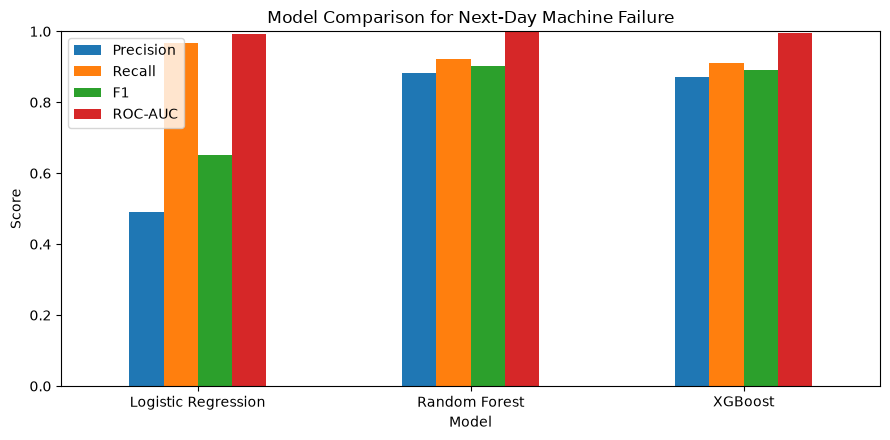

In [36]:
# comparison chart
ax = comparison[
    ["Precision", "Recall", "F1", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(9, 4.5),
    rot=0
)

ax.set(
    title="Model Comparison for Next-Day Machine Failure",
    ylabel="Score",
    xlabel="Model",
    ylim=(0, 1)
)

plt.tight_layout()
plt.show()

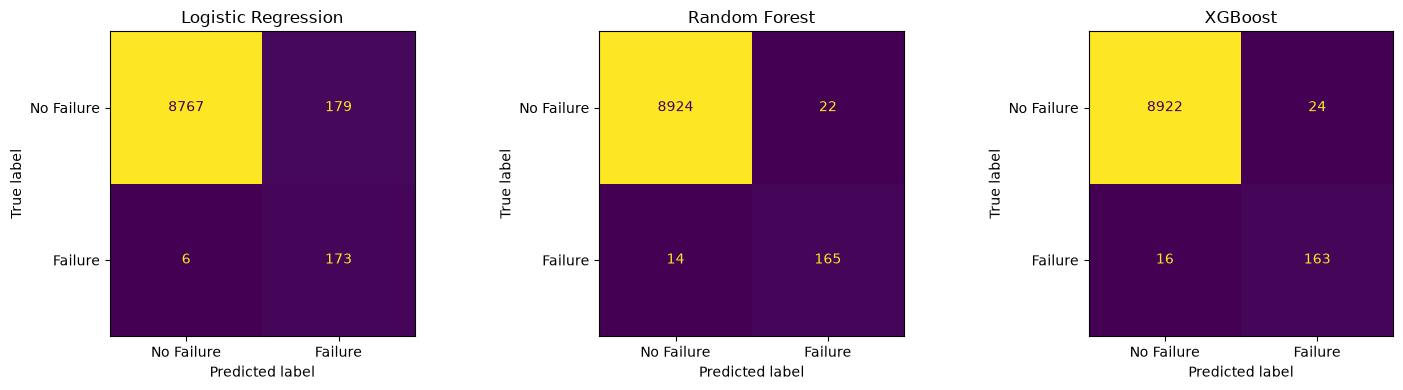

In [37]:
# confusion matrix 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, final_models.items()):

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        colorbar=False,
        display_labels=["No Failure", "Failure"]
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

In [38]:
# STEP 9 - DATA LEAKAGE DEMONSTRATION
# This is intentionally WRONG.
# We include failure_count, which contains information about the target.

leaky_numeric = numeric_features + ["failure_count"]

leaky_pre = ColumnTransformer([
    ("num",
     Pipeline([
         ("impute", SimpleImputer(strategy="median")),
         ("scale", StandardScaler())
     ]),
     leaky_numeric),

    ("cat",
     OneHotEncoder(handle_unknown="ignore"),
     categorical_features)
])

# Features now incorrectly contain failure_count
X_leak = daily[leaky_numeric + categorical_features]

# Split the data
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leak,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

# Train Logistic Regression
leaky_model = Pipeline([
    ("pre", leaky_pre),
    ("clf", LogisticRegression(max_iter=1000))
])

leaky_model.fit(Xl_train, yl_train)

# Predict
leaky_pred = leaky_model.predict(Xl_test)

print(
    "LEAKY F1 =",
    round(f1_score(yl_test, leaky_pred), 4)
)

LEAKY F1 = 0.7195
